In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import glob
import os

from lmfit import Model
from lmfit.models import SineModel, ConstantModel, GaussianModel

In [8]:
OFFRES_DATA = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
               '/Mounted_device_mk_5/10mK/2026_04_08/afc/afc_storage_experiment_30db_offres.npz')
STORAGE_DATA = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                '/Mounted_device_mk_5/10mK/2026_04_08/afc/afc_storage_experiment_30db_storage.npz')

edge_coupling_efficiency = 0.07
snspd_efficiency = 0.5

# read data
data_offres = np.load(OFFRES_DATA, allow_pickle=True)
data_echo = np.load(STORAGE_DATA, allow_pickle=True)
time_storage = data_offres['bins']
time_diff = time_storage[1] - time_storage[0]

# calculate efficiencies
idx_in = np.where(np.logical_and(time_storage > 0.9, time_storage < 1.1))[0]
idx_echo = np.where(np.logical_and(time_storage > 1.9, time_storage < 2.1))[0]
counts_in = np.sum(data_offres['counts'][idx_in])
counts_echo = np.sum(data_echo['counts'][idx_echo])
print('Counts In:', counts_in)
print('Counts Echo:', counts_echo)
print('Efficiency:', counts_echo/counts_in)

# calculate pulse statistics
params = data_offres['storage parameters']
print(params)
# pulse_freq = data_offres['storage parameters']['pulse_freq']
# integration_time = data_offres['storage parameters']['integration_time']
integration_time = 300
pulse_freq = 100e3
num_pulses = integration_time * pulse_freq
total_photons = counts_in / edge_coupling_efficiency / snspd_efficiency
photons_per_pulse = total_photons / num_pulses
print('Total photons on chip:', total_photons)
print('Photons per pulse:', photons_per_pulse)

# fit data to gather reference 0 time
model = GaussianModel() + ConstantModel()
res_input_pulse = model.fit(data_offres['counts'], x=time_storage,
                            center=1)
print(res_input_pulse.fit_report())

center_time = res_input_pulse.params['center'].value

Counts In: 197372
Counts Echo: 15265
Efficiency: 0.0773412642117423
{'integration_time': 300.0, 'bin_width': 1e-09, 'bin_number': 10000, 'pulse_freq': 100000.0, 'pulse_width': 6e-08, 'pulse_atten': 30.0, 'snspd_num': 2}
Total photons on chip: 5639199.999999999
Photons per pulse: 0.1879733333333333
[[Model]]
    (Model(gaussian) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 184
    # data points      = 10000
    # variables        = 4
    chi-square         = 1381280.44
    reduced chi-square = 138.183317
    Akaike info crit   = 49289.8111
    Bayesian info crit = 49318.6524
    R-squared          = 0.99917641
[[Variables]]
    amplitude:  198.455211 +/- 0.06983644 (0.04%) (init = 1)
    center:     0.96994275 +/- 2.6830e-06 (0.00%) (init = 1)
    sigma:      0.00661434 +/- 2.6845e-06 (0.04%) (init = 1)
    c:          0.05967889 +/- 0.11775866 (197.32%) (init = 0)
    fwhm:       0.01557557 +/- 6.3215e-06 (0.04%) == '2.3548200*sigma'
 

In [5]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_no_phase_offset')
one_pulse_offres = 'one_pulse_offres.txt'
one_pulse_storage = 'one_pulse_3_00pi.txt'
two_pulse_offres = 'two_pulse_offres.txt'
pi_to_plot_0 = 0.0
pi_to_plot_1 = 1.0

xlim_interfere = (1.99-0.2, 1.99+0.2)

# gather data
storage_files = glob.glob('two_pulse_*pi.txt', root_dir=DATA_DIR)
storage_files.sort()

# read data
df_0 = None
df_1 = None
for file in storage_files:
    file_path = os.path.join(DATA_DIR, file)
    file_parts = file.split('_')
    pi_fraction = float(file_parts[2]) + (float(file_parts[3][:2])/100)
    if pi_fraction == pi_to_plot_0:
        df_0 = pd.read_csv(file_path, sep='\t')
    elif pi_fraction == pi_to_plot_1:
        df_1 = pd.read_csv(file_path, sep='\t')

time_interfere = df_0['time(ps)']
time_interfere /= 1e6  # convert to us
counts_0 = df_0['counts']
counts_1 = df_1['counts']

idx_to_plot = (time_interfere > xlim_interfere[0]) & (time_interfere < xlim_interfere[1])
time_interfere = time_interfere[idx_to_plot]
counts_0 = counts_0[idx_to_plot]
counts_1 = counts_1[idx_to_plot]

In [17]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (4, 3)
dpi = 300
xlim = (0.9, 3.0)

# colors
color_source = '#7570b3'
color_source_2 = 'darkgray'
color_memory = '#d95f02'
color_memory_2 = 'darkgray'

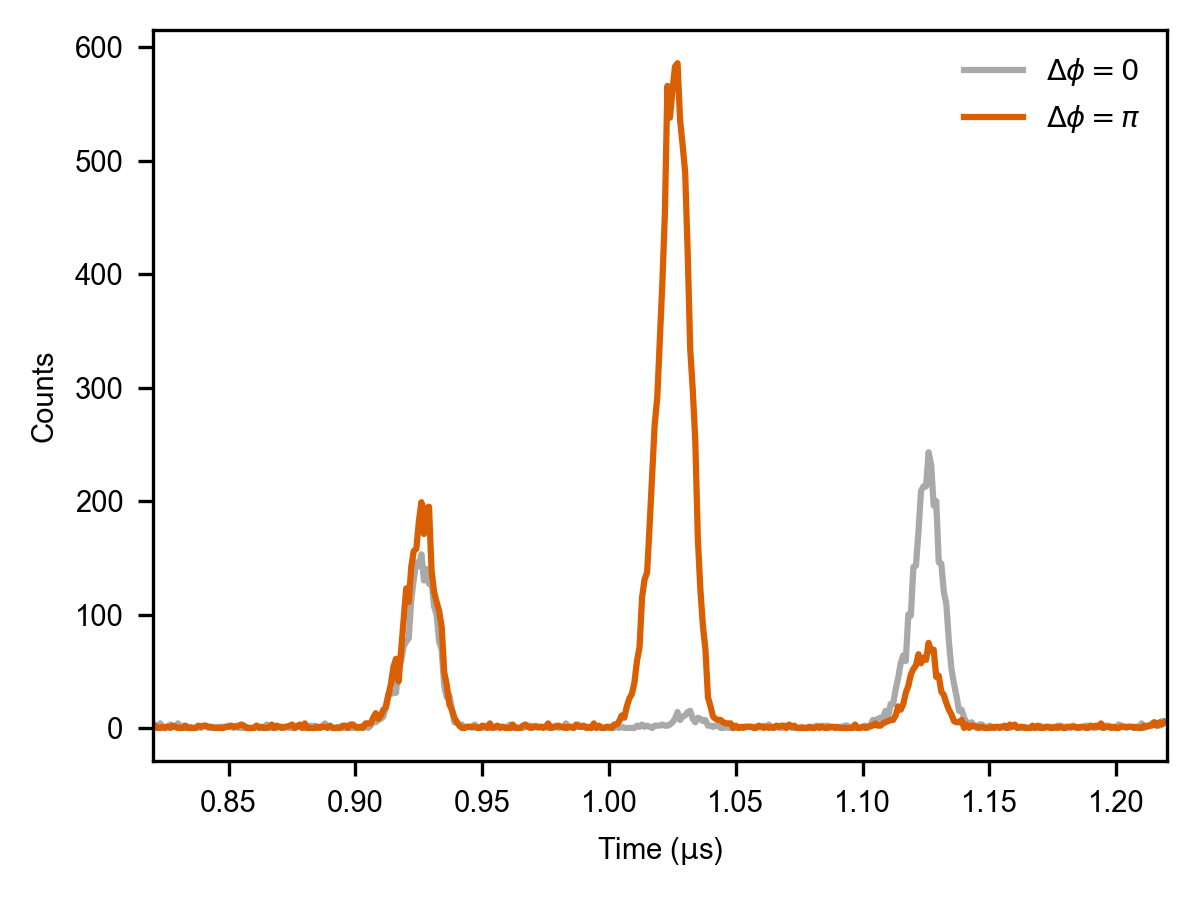

In [26]:
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(time_interfere-center_time, counts_0,
         color=color_memory_2,
         label=r'$\Delta\phi = 0$',)
ax.plot(time_interfere-center_time, counts_1,
         color=color_memory,
         label=r'$\Delta\phi = \pi$')
ax.set_xlim(xlim_interfere-center_time)
ax.set_xlabel(r'Time ($\mathrm{\mu}$s)')
ax.set_ylabel(r'Counts')
ax.legend(frameon=False)
fig.tight_layout()

In [27]:
fig.savefig('sup_afc_interference.pdf')